<a href="https://colab.research.google.com/github/himanshubhimte69/Parameter_Efficient_Deep_Learning-Class_Selective_Knowledge_Distillation_for_Precision_Agriculture/blob/main/tsne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip Plant_Pathology_2020.zip

Archive:  Plant_Pathology_2020.zip
   creating: Plant Pathology 2020/
   creating: Plant Pathology 2020/Images/
   creating: Plant Pathology 2020/Images/healthy/
  inflating: Plant Pathology 2020/Images/healthy/Train_100.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1001.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1002.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1004.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1005.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1007.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1012.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1014.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1017.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1020.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_103.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1031.jpg  
  inflating: Plant Pathology 2020/Images/healthy

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense
)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


In [ ]:
# ============================================================
# 2. CLASS NAMES
# ============================================================

class_names = [
    "healthy",
    "rust",
    "scab"
]

In [ ]:
# ============================================================
# 3. IMAGE SETTINGS
# ============================================================

IMG_SIZE = (380,380)

batch_size = 8


In [ ]:
# ============================================================
# 4. LOAD DATASET
# ============================================================

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Plant Pathology 2020/Images",
    image_size=(380,380),
    batch_size=8,
    label_mode="int",
    shuffle=True
)

print("Dataset loaded")


Found 1730 files belonging to 3 classes.
Dataset loaded


In [ ]:
# ============================================================
# 5. BUILD BASELINE MODEL
# ============================================================

baseline_base = EfficientNetB4(
    include_top=False,
    weights=None,
    input_shape=(380,380,3)
)

baseline_model = tf.keras.Sequential([
    baseline_base,
    GlobalAveragePooling2D(),
    Dense(
        3,
        activation='softmax'
    )
])

baseline_model.build(
    (None,380,380,3)
)

baseline_model.load_weights(
    "/content/basemodel_model_pp2020.h5",
    by_name=True,
    skip_mismatch=True
)

print("Baseline model loaded")

Baseline model loaded


In [ ]:
# ============================================================
# 6. BUILD KD MODEL
# ============================================================

kd_base = EfficientNetB4(
    include_top=False,
    weights=None,
    input_shape=(380,380,3)
)

student_model_pp2020 = tf.keras.Sequential([
    kd_base,
    GlobalAveragePooling2D(),
    Dense(
        3,
        activation='softmax'
    )
])

student_model_pp2020.build(
    (None,380,380,3)
)

student_model_pp2020.load_weights(
    "/content/student_model_pp2020.h5"
)

print("KD student model loaded")

KD student model loaded


In [ ]:
# ============================================================
# 7. INITIALIZE MODELS
# ============================================================

dummy_input = tf.random.normal(
    (1,380,380,3)
)

_ = baseline_model(dummy_input)

_ = student_model_pp2020(dummy_input)

print("Models initialized")


Models initialized


In [ ]:
# ============================================================
# 8. BACKBONES
# ============================================================

baseline_backbone = baseline_model.layers[0]

kd_backbone = student_model_pp2020.layers[0]


In [ ]:
# ============================================================
# 9. FEATURE EXTRACTORS
# ============================================================

baseline_feature_extractor = tf.keras.Model(
    inputs=baseline_backbone.inputs,
    outputs=baseline_backbone.output
)

kd_feature_extractor = tf.keras.Model(
    inputs=kd_backbone.inputs,
    outputs=kd_backbone.output
)

print("Feature extractors ready")


Feature extractors ready


In [ ]:
# ============================================================
# 10. EXTRACT FEATURES
# ============================================================

baseline_features = []

kd_features = []

labels_list = []

print("\nExtracting features...")

for images, labels in test_ds:

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    label_ids = labels.numpy()

    labels_list.extend(label_ids)

    # --------------------------------------------------------
    # BASELINE FEATURES
    # --------------------------------------------------------

    baseline_feat = baseline_feature_extractor.predict(
        images,
        verbose=0
    )

    # GAP pooling
    baseline_feat = np.mean(
        baseline_feat,
        axis=(1,2)
    )

    # IMPORTANT
    baseline_features.append(
        baseline_feat
    )

    # --------------------------------------------------------
    # KD FEATURES
    # --------------------------------------------------------

    kd_feat = kd_feature_extractor.predict(
        images,
        verbose=0
    )

    # GAP pooling
    kd_feat = np.mean(
        kd_feat,
        axis=(1,2)
    )

    # IMPORTANT
    kd_features.append(
        kd_feat
    )


Extracting features...


In [ ]:
# ============================================================
# 11. CONCATENATE CORRECTLY
# ============================================================

baseline_features = np.vstack(
    baseline_features
)

kd_features = np.vstack(
    kd_features
)

labels_array = np.array(
    labels_list
)

# ============================================================
# CHECKS
# ============================================================

print("\nFeature Shapes:")

print(
    "Baseline:",
    baseline_features.shape
)

print(
    "KD:",
    kd_features.shape
)

print("\nLabel Distribution:")

unique, counts = np.unique(
    labels_array,
    return_counts=True
)

for u, c in zip(unique, counts):

    print(
        class_names[u],
        ":",
        c
    )



Feature Shapes:
Baseline: (1730, 1792)
KD: (1730, 1792)

Label Distribution:
healthy : 516
rust : 622
scab : 592


In [ ]:
# ============================================================
# 12. STANDARDIZE FEATURES
# ============================================================

from sklearn.preprocessing import StandardScaler

baseline_scaler = StandardScaler()

baseline_features = baseline_scaler.fit_transform(
    baseline_features
)

kd_scaler = StandardScaler()

kd_features = kd_scaler.fit_transform(
    kd_features
)

print("\nFeatures standardized successfully")


Features standardized successfully


In [ ]:
# ============================================================
# 13. RUN t-SNE
# ============================================================

print("\nRunning t-SNE for baseline...")

baseline_tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    learning_rate='auto',
    init='pca'
).fit_transform(baseline_features)

print("Running t-SNE for KD student...")

kd_tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    learning_rate='auto',
    init='pca'
).fit_transform(kd_features)



Running t-SNE for baseline...
Running t-SNE for KD student...


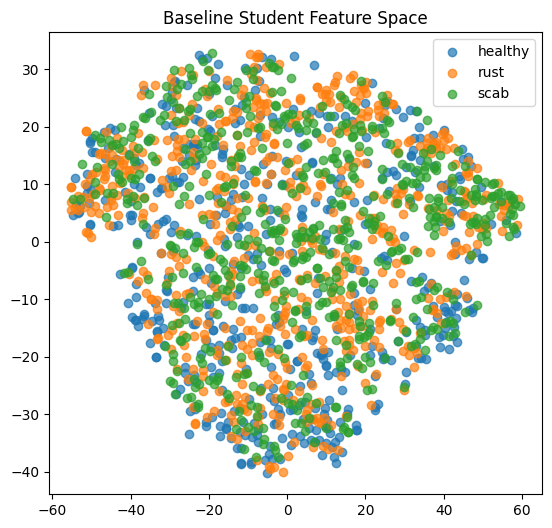

In [ ]:
# ============================================================
# 14. VISUALIZATION
# ============================================================

plt.figure(figsize=(14,6))

# ============================================================
# BASELINE PLOT
# ============================================================

plt.subplot(1,2,1)

for class_id, class_name in enumerate(class_names):

    idx = labels_array == class_id

    plt.scatter(
        baseline_tsne[idx,0],
        baseline_tsne[idx,1],
        label=class_name,
        alpha=0.7
    )

plt.title(
    "Baseline Student Feature Space"
)

plt.legend()

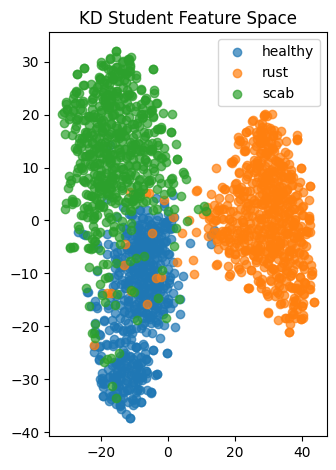

In [ ]:
# ============================================================
# KD PLOT
# ============================================================

plt.subplot(1,2,2)

for class_id, class_name in enumerate(class_names):

    idx = labels_array == class_id

    plt.scatter(
        kd_tsne[idx,0],
        kd_tsne[idx,1],
        label=class_name,
        alpha=0.7
    )

plt.title(
    "KD Student Feature Space"
)

plt.legend()

plt.tight_layout()



Saved successfully:
/content/tsne_comparison.png


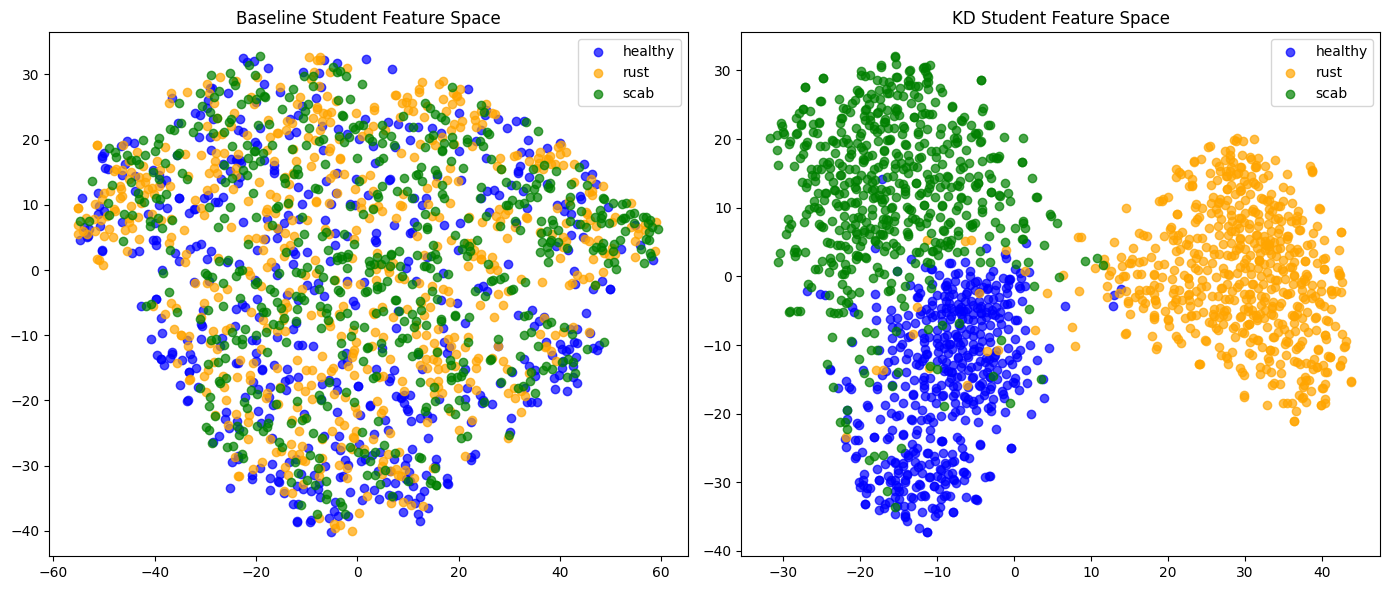

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# 14. VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,6)
)

# ============================================================
# BASELINE PLOT
# ============================================================

colors = ['blue', 'orange', 'green']

for class_id, class_name in enumerate(class_names):

    idx = labels_array == class_id

    axes[0].scatter(
        baseline_tsne[idx,0],
        baseline_tsne[idx,1],
        label=class_name,
        color=colors[class_id],
        alpha=0.7
    )

axes[0].set_title(
    "Baseline Student Feature Space"
)

axes[0].legend()

# ============================================================
# KD PLOT
# ============================================================

for class_id, class_name in enumerate(class_names):

    idx = labels_array == class_id

    axes[1].scatter(
        kd_tsne[idx,0],
        kd_tsne[idx,1],
        label=class_name,
        color=colors[class_id],
        alpha=0.7
    )

axes[1].set_title(
    "KD Student Feature Space"
)

axes[1].legend()

# ============================================================
# SAVE
# ============================================================

save_path = "/content/tsne_comparison.png"

fig.tight_layout()

fig.savefig(
    save_path,
    dpi=300
)

print("\nSaved successfully:")
print(save_path)

# ============================================================
# SHOW
# ============================================================

plt.show()

# ============================================================
# DOWNLOAD
# ============================================================

from google.colab import files

files.download(save_path)